# Machine Learning Classifier for Lung Disease

## Convolutional Neural Network

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tqdm import tqdm

In [5]:
def load_lung_disease_dataset_cnn(base_path, img_size=(224, 224)):
    data = []
    labels = []
    
    if not os.path.exists(base_path):
        print(f"Error: Path {base_path} not found.")
        return None, None
        
    class_names = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))])
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    for idx, label in enumerate(class_names):
        folder_path = os.path.join(base_path, label)
        files = os.listdir(folder_path)
        
        for img_name in tqdm(files, desc=f"Loading {label}", leave=False):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            img = clahe.apply(img)
            img = cv2.resize(img, img_size)
            
            data.append(img / 255.0)
            labels.append(idx)
            
    return np.array(data, dtype=np.float32), np.array(labels, dtype=np.int32)

### Load Data set

In [6]:
X, y = load_lung_disease_dataset_cnn('1/dataset_combined')

### Split Dataset
- Three-Way Split (Train 70%, Val 15%, Test 15%)

In [8]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)

X_train = X_train.reshape(-1, 224, 224, 1)
X_val = X_val.reshape(-1, 224, 224, 1)
X_test = X_test.reshape(-1, 224, 224, 1)

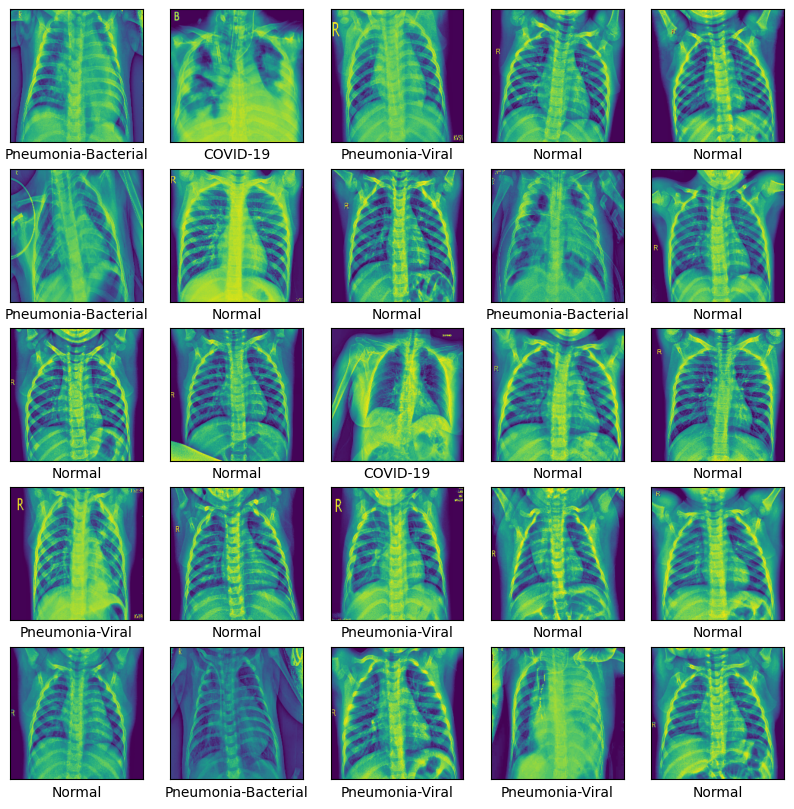

In [11]:
classes = ["COVID-19", "Normal", "Pneumonia-Bacterial", "Pneumonia-Viral"]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(classes[y_train[i]])
plt.show()

In [15]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,075,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,132,042 (42.47 MB)

 Trainable params: 11,132,042 (42.47 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_val, y_val))

Epoch 1/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.7123 - loss: 0.7847 - val_accuracy: 0.7983 - val_loss: 0.5137
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.8246 - loss: 0.4300 - val_accuracy: 0.8266 - val_loss: 0.4317
Epoch 3/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.8531 - loss: 0.3489 - val_accuracy: 0.7961 - val_loss: 0.4649
Epoch 4/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.8882 - loss: 0.2714 - val_accuracy: 0.8433 - val_loss: 0.4023
Epoch 5/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.9223 - loss: 0.1947 - val_accuracy: 0.8374 - val_loss: 0.4351
Epoch 6/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.9480 - loss: 0.1340 - val_accuracy: 0.8280 - val_loss: 0.4728
Epoch 7/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9774 - loss: 0.0647 - val_accuracy: 0.8498 - val_loss: 0.6066
Epoch 8/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.9862 - loss: 0.0411 - val_accu


Evaluating best model on unseen Test Set...
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 309ms/step
              precision    recall  f1-score   support

           0       0.98      0.82      0.90       192
           1       0.94      0.95      0.95       491
           2       0.79      0.84      0.82       450
           3       0.66      0.67      0.66       249

    accuracy                           0.84      1382
   macro avg       0.84      0.82      0.83      1382
weighted avg       0.85      0.84      0.85      1382



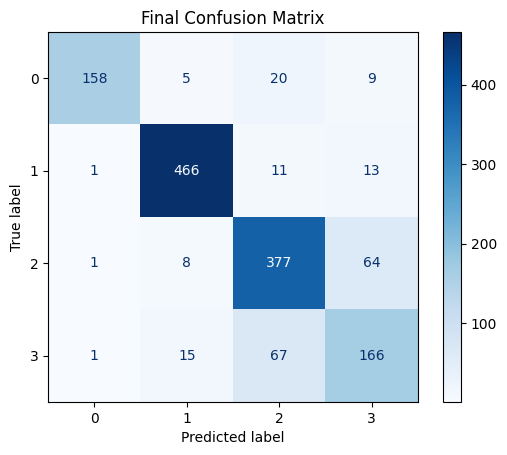

In [20]:
print("\nEvaluating best model on unseen Test Set...")
all_preds = model.predict(X_test)

predicted_classes = np.argmax(all_preds, axis=1)

print(classification_report(y_test, predicted_classes))

y_test_flat = y_test.flatten().astype(np.int32)

cm = confusion_matrix(y_test_flat, predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Final Confusion Matrix")
plt.show()

In [21]:
model.save('lung_disease_model_cnn.keras')